In [7]:
import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
import time

In [8]:
toy_example = True
c = torch.load('data/c.pt', weights_only=True)
d = torch.load('data/d.pt', weights_only=True)
A = torch.load('data/A.pt', weights_only=True)
H = torch.load('data/H.pt', weights_only=True)

dimX = A.shape[0]; dimY = A.shape[1];

def f(x, y):
    return torch.sin(c.T @ x + d.T @ y) + torch.log(torch.linalg.norm(x+y)**2 + 1)

def g(x, y):
    return 0.5 * torch.linalg.norm(H@y - x)**2


In [9]:
def calc_derivatives(x, y):
    f_val = f(x,y)
    g_val = g(x,y)

    # 1st derivatives
    dfdy = torch.autograd.grad(f_val, y, create_graph=True, allow_unused=True, materialize_grads=True)[0]
    dfdx = torch.autograd.grad(f_val, x, create_graph=True, allow_unused=True, materialize_grads=True)[0]

    dgdy = torch.autograd.grad(g_val, y, create_graph=True, allow_unused=True, materialize_grads=True)[0]
    dgdx = torch.autograd.grad(g_val, x, create_graph=True, allow_unused=True, materialize_grads=True)[0]

    # Initialize tensors for 2nd derivatives
    dgdyy = torch.zeros((dimY, dimY))
    dgdyx = torch.zeros((dimY, dimX))
    # Compute 2nd derivatives element-wise
    for i in range(dgdy.shape[0]):
        dgdyy[i, :] = torch.autograd.grad(dgdy[i], y, retain_graph=True, create_graph=True, allow_unused=True, materialize_grads=True)[0][:, 0]
        dgdyx[i, :] = torch.autograd.grad(dgdy[i], x, retain_graph=True, create_graph=True, allow_unused=True, materialize_grads=True)[0][:, 0]
    
    return dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx

def calc_derivatives_analytic(x, y):
    if toy_example:
        dfdx = torch.cos(c.T @ x + d.T @ y) * c + 2 *(x+y) / (torch.linalg.norm(x+y)**2 + 1)
        dfdy = torch.cos(c.T @ x + d.T @ y) * d + 2 * (x+y) / (torch.linalg.norm(x+y)**2 + 1)

        dgdx = - (H @ y - x)
        dgdy = H.T @ (H @ y - x)

        dgdyy = H.T @ H
        dgdyx = -H
    
    else:
        pass

    return dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx

if toy_example: calc_derivatives = calc_derivatives_analytic

In [10]:
def solveLL(x):
    y = torch.randn((dimY, 1), requires_grad=True, dtype=torch.float32)
    lr = 1e-1
    while True:
        dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx = calc_derivatives(x, y)
        HessianInv = dgdyy.inverse()
        if torch.linalg.norm(dgdy, 2) < 1e-3:
            break
        with torch.no_grad():
            y -= lr * HessianInv @ dgdy
    return y

def system(t, variables):
    x, y = variables[:dimX], variables[dimX:]
    global dxdt #Because its previous value is required in ProjectMethod 1
    
    dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx = calc_derivatives(x, y)
    with torch.no_grad():    
        if method == 'IFCT':
            a = 2 * dgdyx.T @ dgdy
            b = 2 * dgdyy @ dgdy
            c = -alpha * (torch.linalg.norm(dgdy, 2)**2 - epsilon**2)
            ab = torch.cat((a, b), 0)

            tot = torch.cat((dfdx, dfdy), 0)
            d = ab * torch.maximum(torch.Tensor([0]), -ab.T @ tot - c) / (torch.linalg.norm(a, 2)**2 + torch.linalg.norm(b, 2)**2)
            dtotdt = -tot - d
            dxdt = dtotdt[:dimX]; dydt = dtotdt[dimX:]
            
            if torch.linalg.norm(dgdy, 2) > epsilon and not torch.allclose(torch.linalg.norm(dgdy, 2), torch.Tensor([epsilon])):
                print('t=',t, '-', torch.linalg.norm(dgdy, 2), epsilon)
        #  
        elif method == 'IFCT2':
            a = 2 * dgdyx.T @ dgdy
            b = 2 * dgdyy @ dgdy
            c = -alpha * (torch.linalg.norm(dgdy, 2)**2)
            ab = torch.cat((a, b), 0)

            tot = torch.cat((dfdx, dfdy), 0)
            d = ab * -ab.T @ tot - c / (torch.linalg.norm(a, 2)**2 + torch.linalg.norm(b, 2)**2)
            dtotdt = -tot - d
            dxdt = dtotdt[:dimX]; dydt = dtotdt[dimX:]
            
            if torch.linalg.norm(dgdy, 2) > epsilon and not torch.allclose(torch.linalg.norm(dgdy, 2), torch.Tensor([epsilon])):
                print('t=',t, '-', torch.linalg.norm(dgdy, 2), epsilon)
        elif method == 'NewSecondOrder':
            a = dgdyx @ dgdyx.T
            b = dgdyy @ dgdyy.T
            c = -alpha * dgdy + dgdyx @ dfdx + dgdyy @ dfdy
            lam = -torch.inverse(a + b) @ c

            dxdt = -dfdx - dgdyx.T @ lam
            dydt = -dfdy - dgdyy.T @ lam

        elif method == 'SecondOrder':
            mu = 0.05
            gHessianInv = dgdyy.inverse()
            dxdt = -dfdx + dgdyx.T @ gHessianInv @ dfdy
            dydt = -gHessianInv @ (mu * dgdy + dgdyx @ dxdt)  
        # 
        elif method == 'STABLE':
            mu1 = 1
            mu2 = 0.1
            gHessianInv = dgdyy.inverse()
            dxdt = mu1 * (-dfdx + dgdyx.T @ gHessianInv @ dfdy)
            dydt = -mu2 * dgdy - gHessianInv @ dgdyx @ dxdt 
        
        else:
            raise ValueError('Invalid method')
    
    return torch.cat((dxdt, dydt), 0)


# Define the system of ODEs
def system2(t, variables):
    x, y, nu = variables[:dimX], variables[dimX:dimX+dimY], variables[dimX+dimY:]
    global dxdt #Because its previous value is required in ProjectMethod 1
    
    dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx = calc_derivatives(x, y)
    F = torch.cat((dfdx + dgdyx.T @ nu, 
                    dfdy + dgdyy.T @ nu,
                    dgdy), 0)
    
    
    # Initialize Jacobian matrices
    dFdx = torch.zeros(F.shape[0], x.shape[0])
    dFdy = torch.zeros(F.shape[0], y.shape[0])
    dFnu = torch.zeros(F.shape[0], nu.shape[0])
    
    # Compute Jacobians by looping over each component of F
    for i in range(F.shape[0]):
        dFdx[i, :] = torch.autograd.grad(F[i], x, retain_graph=True, create_graph=True, allow_unused=True, materialize_grads=True)[0][:, 0]
        dFdy[i, :] = torch.autograd.grad(F[i], y, retain_graph=True, create_graph=True,  allow_unused=True, materialize_grads=True)[0][:, 0]
        dFnu[i, :] = torch.autograd.grad(F[i], nu, retain_graph=True, create_graph=True,  allow_unused=True, materialize_grads=True)[0][:, 0]

    # Concatenate Jacobian matrices and ensure the matrix is square for inversion
    concat_matrix = torch.cat((dFdx, dFdy, dFnu), 1)
    vars = - 1 * concat_matrix.inverse() @ F
    dxdt = vars[:dimX]
    dydt = vars[dimX:dimX+dimY]
    dnudt = vars[dimX+dimY:]
    
    return torch.cat((dxdt, dydt, dnudt), 0)

In [11]:
def plot_results(solutions, scenarios, axs, figs, t):
    plt.rcParams.update({'font.size': 13})

    lines=[]
    if toy_example:
        fig1, fig11, fig2 = figs
        ax1, ax11, ax2 = axs
    else:
        fig1, fig11, fig2, fig3, fig4 = figs
        ax1, ax11, ax2, ax3, ax4 = axs
    
    flag_method, flag_alpha, flag_epsilon = 1, 1, 1
    try:
        if scenarios[0][0] == scenarios[1][0]: flag_method = 0
        if scenarios[0][1] == scenarios[1][1]: flag_alpha = 0
        if scenarios[0][2] == scenarios[1][2]: flag_epsilon = 0
    except:
        flag_alpha, flag_epsilon = 0, 0

    for (solution, scenario) in zip(solutions, scenarios):
        method, alpha, epsilon = scenario
        lossF, lossG, lossF2 = [], [], []
        for i in range(len(solution)):
            lossF.append(f(solution[i, :dimX], solution[i, dimX:dimX+dimY])[0].detach().numpy())
            dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx = calc_derivatives(solution[i, :dimX], solution[i, dimX:dimX+dimY])
            lossG.append(torch.linalg.norm(dgdy).detach().numpy())
            lossF2.append(torch.linalg.norm(dfdx - dgdyx.T @ dgdyy.inverse() @ dfdy).detach().numpy())


        strLabel = ((r': $\alpha$= ' + str(alpha)) if flag_alpha else r': $\varepsilon$= ' + str(epsilon) if method == 'IFCT' else '')
        ax1.plot(t, lossF, label= (method + strLabel))
        ax11.plot(t, lossF2, label=(method + strLabel))
        
        # -----------------------------------------------------
        ax2.plot(t, lossG, label=(method + strLabel))
        ax2.plot(t, [epsilon] * len(t), 'r--')



    ax1.legend()
    ax1.set_xlabel('time', fontsize=14)
    ax1.set_ylabel('f(x,y)', fontsize=14)

    ax11.legend()
    ax11.set_xlabel('time', fontsize=14)
    ax11.set_ylabel(r'$\|\nabla F(x,y)\|$', fontsize=14)
    ax11.set_yscale('log')

    ax2.legend()
    ax2.set_xlabel('time', fontsize=14)
    ax2.set_ylabel(r'$\|\nabla g(x,y)\|$', fontsize=14)
    # ax2.set_ylim([0, 1.25 * epsilon])


    # plt.tight_layout()
    scenarioItems = ['method', 'alpha', 'epsilon']
    item = 2 * flag_epsilon + 1 * flag_alpha + 0 * flag_method
    fig1.savefig('Result/' + ('toy_example/' if toy_example else 'DHC/') + scenarioItems[item] + ':' + str(scenarios[0][item]) + '-up1' + '.pdf', dpi=300)
    fig11.savefig('Result/' + ('toy_example/' if toy_example else 'DHC/') + scenarioItems[item] + ':' + str(scenarios[0][item]) + '-up2' + '.pdf', dpi=300)
    fig2.savefig('Result/' + ('toy_example/' if toy_example else 'DHC/') + scenarioItems[item] + ':' + str(scenarios[0][item]) + '-low' + '.pdf', dpi=300)


LL error:  tensor(0.0009, grad_fn=<AmaxBackward0>)
Time taken: 47.37403416633606
LL error:  tensor(0.0009, grad_fn=<AmaxBackward0>)
Time taken: 0.4278690814971924


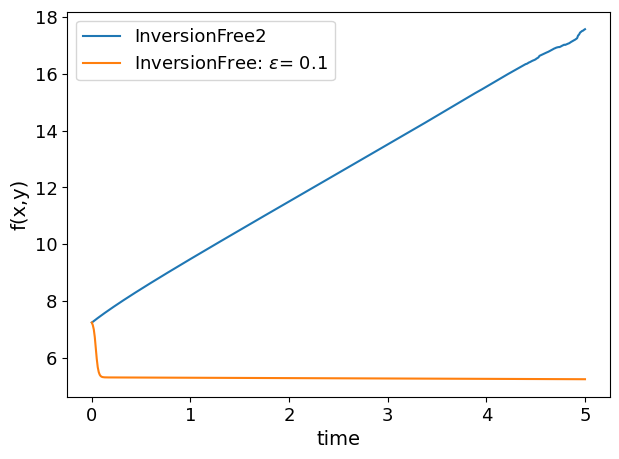

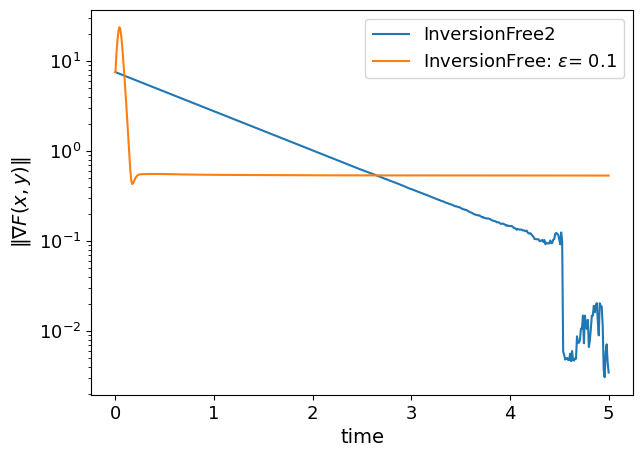

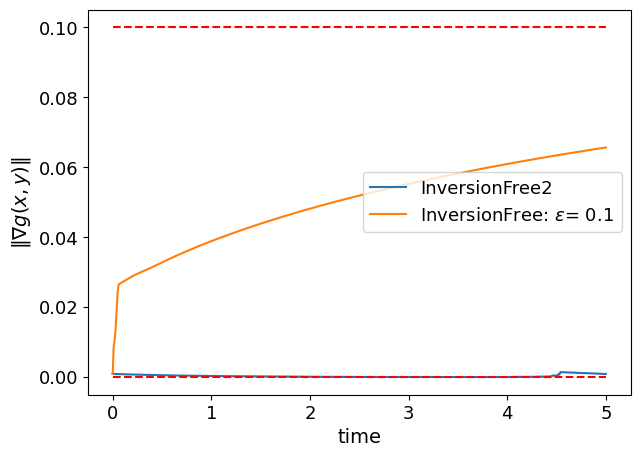

In [12]:
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))
# ax11 = ax1.twinx()
fig11, ax11 = plt.subplots(1, 1, figsize=(7, 5))
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))
if not toy_example:
    fig3, ax3 = plt.subplots(1, 1, figsize=(7, 5))
    fig4, ax4 = plt.subplots(1, 1, figsize=(7, 5))
    axs = [ax1, ax11, ax2, ax3, ax4]
    figs = [fig1, fig11, fig2, fig3, fig4]
else:
    axs = [ax1, ax11, ax2]
    figs = [fig1, fig11, fig2]

scenarioAlpha = [('IFCT', 0.01, 0.1), ('IFCT', 0.05, 0.1), ('IFCT', 0.1, 0.1), ('IFCT', 0.5, 0.1), ('IFCT', 1, 0.1)]
scenarioEps = [('IFCT', 0.1, 0.05), ('IFCT', 0.1, 0.1), ('IFCT', 0.1, 0.5), ('IFCT', 0.1, 1)]
scenario2nd = [('SecondOrder', 0.1, 0.1), ('NewSecondOrder', 0.1, 0.1), ('IFCT', 0.1, 0.1)]
scenarioDHC = [('SecondOrder', 0.1, 0.5), ('NewSecondOrder', 0.1, 0.5), ('IFCT', 0.1, 0.5)]
# ('InversionFroo', 0.1, 0.05), ('IFCT', 0.1, 0.05)
scenarioTest = [('IFCT2', 0.1, 0.0), ('IFCT', 0.1, 0.1)]
# 
scenarios = scenarioTest
solutions = []
for (method, alpha, epsilon) in scenarios:
    torch.manual_seed(0)
    x = torch.randn((dimX, 1), requires_grad=True, dtype=torch.float32)
    nu = torch.zeros((dimY, 1), requires_grad=True, dtype=torch.float32)
    # else:
    #     x = torch.ones((dimX, 1), requires_grad=True, dtype=torch.float32)
    y = solveLL(x)
    dfdx, dfdy, dgdx, dgdy, dgdyy, dgdyx = calc_derivatives(x, y)
    print('LL error: ', torch.linalg.norm(dgdy, 2))
    if toy_example:
        t = torch.linspace(0, 5, 500)
    else:
        t = torch.linspace(0, 1, 10)


    # Solve the system of ODEs
    dxdt = torch.zeros((dimX, 1))
    t1 = time.time()


    if method == 'IFCT':
        initial_conditions = torch.cat((x, y), 0)
        solution = torchdiffeq.odeint(system, initial_conditions, t, method='rk4')
    else:
        initial_conditions = torch.cat((x, y, nu), 0)
        solution = torchdiffeq.odeint(system2, initial_conditions, t, method='rk4')
    
    
    print('Time taken:', time.time() - t1)
    solutions.append(solution)

plot_results(solutions, scenarios, axs, figs, t)
